# Phase 1: Byzantine Defense Benchmark Analysis

This notebook analyzes the CIFAR-10 federated learning benchmark results for Byzantine-resilient aggregation methods.

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.size'] = 10

RESULTS_DIR = Path('/Users/asadr/Desktop/gradient-integrity-akash/results')
FIGURES_DIR = Path('/Users/asadr/Desktop/gradient-integrity-akash/figures')
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Load results
with open(RESULTS_DIR / 'cifar10_7252ae14.json') as f:
    data = json.load(f)

results = data['results']
print(f"Loaded {len(results)} experiment results")

Loaded 25 experiment results


In [2]:
# Build summary matrices
defenses = ['FedAvg', 'Krum', 'MultiKrum', 'TrMean', 'Median', 'GeoMed']
attacks = ['Clean', 'SignFlipping', 'ALIE', 'IPM', 'Backdoor']

mta_matrix = np.zeros((len(defenses), len(attacks)))
asr_matrix = np.zeros((len(defenses), len(attacks)))

for r in results:
    d_idx = defenses.index(r['defense'])
    a_idx = attacks.index(r['attack'])
    mta_matrix[d_idx, a_idx] = r['final_mta']
    asr_matrix[d_idx, a_idx] = r['final_asr']

# Convert to percentages
mta_pct = mta_matrix * 100
asr_pct = asr_matrix * 100

print("MTA Matrix (%):")
print(np.round(mta_pct, 1))
print("\nASR Matrix (%):")
print(np.round(asr_pct, 1))

MTA Matrix (%):
[[44.4 41.8 13.4 44.9 59.2]
 [ 0.  16.4 16.6 15.2 22.8]
 [ 0.  24.3 39.7 33.9 45.8]
 [ 0.  34.5 15.4 34.1 55.4]
 [ 0.  34.9 12.9 33.  53.9]
 [ 0.  43.8 22.5 41.7 56.9]]

ASR Matrix (%):
[[ 0.   9.8  0.   1.6  9.9]
 [ 0.   0.   0.   0.  11.8]
 [ 0.   8.4  6.7  0.8  4.7]
 [ 0.   6.3  0.   5.1 10.4]
 [ 0.   7.4  0.   1.  12.2]
 [ 0.   6.2  1.8  7.   8.2]]


## 1. MTA Heatmap (Defense × Attack)

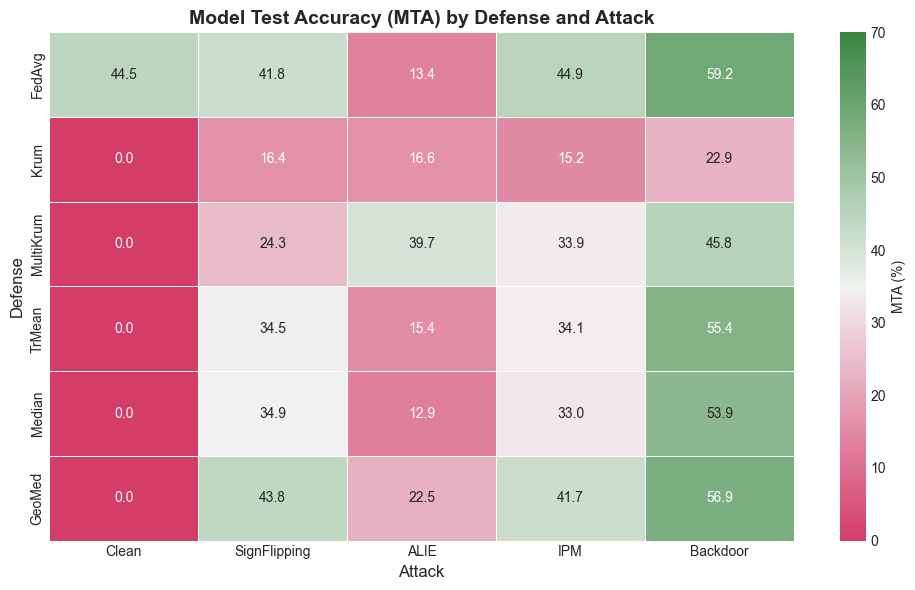

Saved: /Users/asadr/Desktop/gradient-integrity-akash/figures/heatmap_mta.png


In [3]:
fig, ax = plt.subplots(figsize=(10, 6))

# Red to green colormap
cmap = sns.diverging_palette(0, 130, as_cmap=True)

sns.heatmap(mta_pct, annot=True, fmt='.1f', cmap=cmap,
            xticklabels=attacks, yticklabels=defenses,
            cbar_kws={'label': 'MTA (%)'}, ax=ax,
            vmin=0, vmax=70, linewidths=0.5, linecolor='white')

ax.set_xlabel('Attack', fontsize=12)
ax.set_ylabel('Defense', fontsize=12)
ax.set_title('Model Test Accuracy (MTA) by Defense and Attack', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'heatmap_mta.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR / 'heatmap_mta.png'}")

## 2. ASR Heatmap (Defense × Attack)

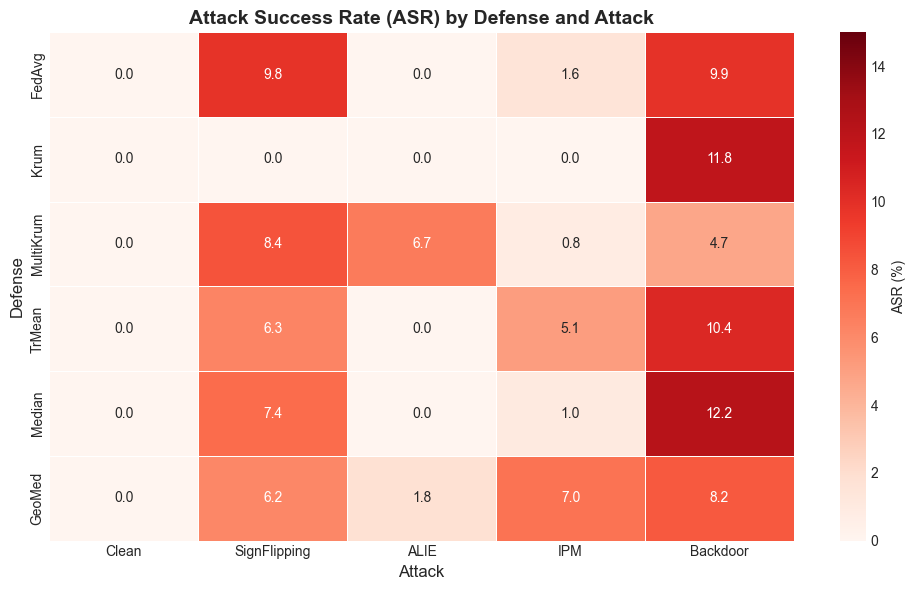

Saved: /Users/asadr/Desktop/gradient-integrity-akash/figures/heatmap_asr.png


In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.heatmap(asr_pct, annot=True, fmt='.1f', cmap='Reds',
            xticklabels=attacks, yticklabels=defenses,
            cbar_kws={'label': 'ASR (%)'}, ax=ax,
            vmin=0, vmax=15, linewidths=0.5, linecolor='white')

ax.set_xlabel('Attack', fontsize=12)
ax.set_ylabel('Defense', fontsize=12)
ax.set_title('Attack Success Rate (ASR) by Defense and Attack', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'heatmap_asr.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR / 'heatmap_asr.png'}")

## 3. MTA and ASR Over Rounds (Backdoor Attack)

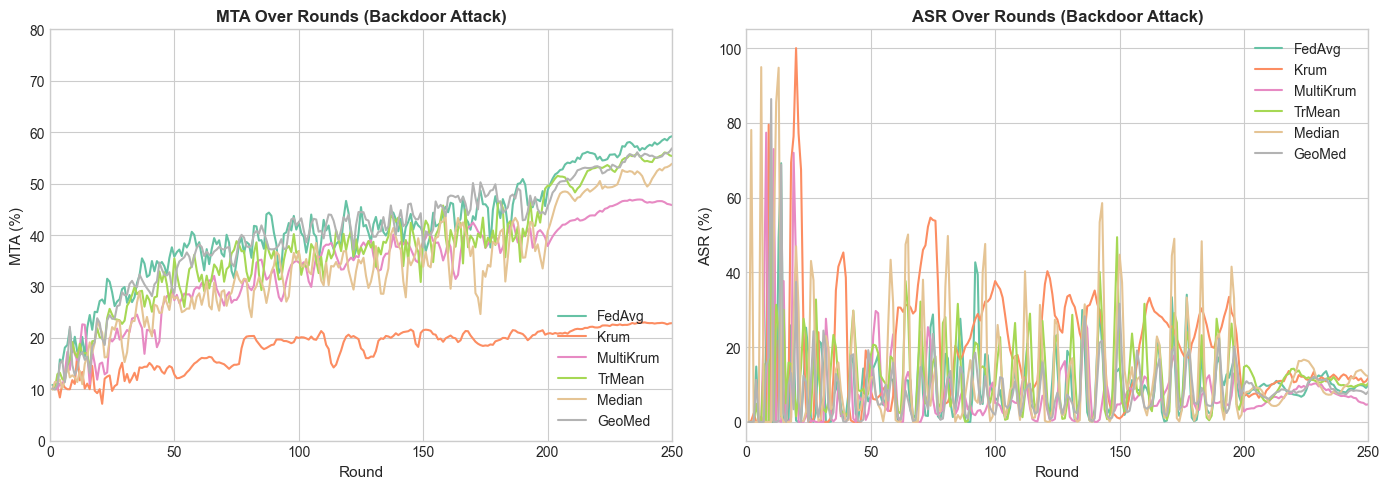

Saved: /Users/asadr/Desktop/gradient-integrity-akash/figures/backdoor_training_curves.png


In [5]:
# Extract backdoor results
backdoor_results = {d: None for d in defenses}
for r in results:
    if r['attack'] == 'Backdoor':
        backdoor_results[r['defense']] = r

# Plot MTA over rounds
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = plt.cm.Set2(np.linspace(0, 1, len(defenses)))

for i, defense in enumerate(defenses):
    data = backdoor_results[defense]
    if data:
        rounds = [d['round'] for d in data['rounds']]
        mtas = [d['mta'] * 100 for d in data['rounds']]
        axes[0].plot(rounds, mtas, label=defense, color=colors[i], linewidth=1.5)

axes[0].set_xlabel('Round', fontsize=11)
axes[0].set_ylabel('MTA (%)', fontsize=11)
axes[0].set_title('MTA Over Rounds (Backdoor Attack)', fontsize=12, fontweight='bold')
axes[0].legend(loc='lower right', framealpha=0.9)
axes[0].set_xlim(0, 250)
axes[0].set_ylim(0, 80)

# Plot ASR over rounds
for i, defense in enumerate(defenses):
    data = backdoor_results[defense]
    if data:
        rounds = [d['round'] for d in data['rounds']]
        asrs = [d['asr'] * 100 for d in data['rounds']]
        axes[1].plot(rounds, asrs, label=defense, color=colors[i], linewidth=1.5)

axes[1].set_xlabel('Round', fontsize=11)
axes[1].set_ylabel('ASR (%)', fontsize=11)
axes[1].set_title('ASR Over Rounds (Backdoor Attack)', fontsize=12, fontweight='bold')
axes[1].legend(loc='upper right', framealpha=0.9)
axes[1].set_xlim(0, 250)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'backdoor_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR / 'backdoor_training_curves.png'}")

## 4. MTA Delta from Clean Baseline (SignFlipping Attack)

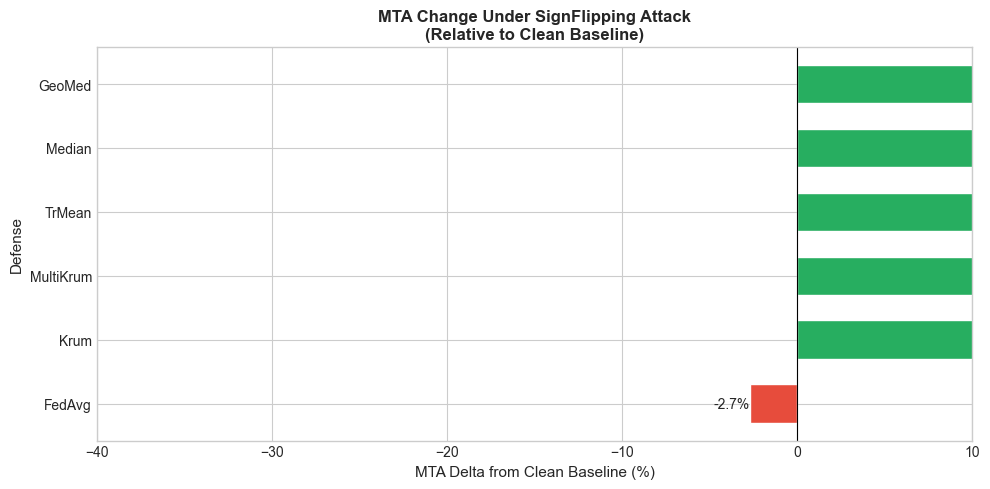

Saved: /Users/asadr/Desktop/gradient-integrity-akash/figures/bar_mta_delta_signflipping.png


In [6]:
# Get clean baseline
clean_mta = {d: 0 for d in defenses}
for r in results:
    if r['attack'] == 'Clean':
        clean_mta[r['defense']] = r['final_mta']

# Get SignFlipping results
signflip_mta = {d: 0 for d in defenses}
for r in results:
    if r['attack'] == 'SignFlipping':
        signflip_mta[r['defense']] = r['final_mta']

# Calculate delta
deltas = [(signflip_mta[d] - clean_mta[d]) * 100 for d in defenses]

fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#e74c3c' if d < 0 else '#27ae60' for d in deltas]
bars = ax.barh(defenses, deltas, color=colors, edgecolor='white', height=0.6)

ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('MTA Delta from Clean Baseline (%)', fontsize=11)
ax.set_ylabel('Defense', fontsize=11)
ax.set_title('MTA Change Under SignFlipping Attack\n(Relative to Clean Baseline)', fontsize=12, fontweight='bold')

for bar, delta in zip(bars, deltas):
    width = bar.get_width()
    ax.annotate(f'{delta:+.1f}%',
                xy=(width, bar.get_y() + bar.get_height()/2),
                ha='left' if delta >= 0 else 'right', va='center',
                fontsize=10)

ax.set_xlim(-40, 10)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'bar_mta_delta_signflipping.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {FIGURES_DIR / 'bar_mta_delta_signflipping.png'}")

## 5. Summary Statistics

In [7]:
# Generate summary table
summary_data = []

for defense in defenses:
    row = {'Defense': defense}
    
    # Clean
    clean = next((r for r in results if r['defense'] == defense and r['attack'] == 'Clean'), None)
    row['Clean MTA'] = f"{clean['final_mta']*100:.1f}%" if clean else 'N/A'
    
    # Untargeted attacks
    untargeted_mtas = []
    for attack in ['SignFlipping', 'ALIE', 'IPM']:
        r = next((x for x in results if x['defense'] == defense and x['attack'] == attack), None)
        if r:
            untargeted_mtas.append(r['final_mta'] * 100)
    row['Untargeted Avg'] = f"{np.mean(untargeted_mtas):.1f}%" if untargeted_mtas else 'N/A'
    
    # Backdoor
    backdoor = next((r for r in results if r['defense'] == defense and r['attack'] == 'Backdoor'), None)
    row['Backdoor MTA'] = f"{backdoor['final_mta']*100:.1f}%" if backdoor else 'N/A'
    row['Backdoor ASR'] = f"{backdoor['final_asr']*100:.1f}%" if backdoor else 'N/A'
    
    summary_data.append(row)

# Print markdown table
print("| " + " | ".join(summary_data[0].keys()) + " |")
print("|" + "---|" * len(summary_data[0]))
for row in summary_data:
    print("| " + " | ".join(row.values()) + " |")

| Defense | Clean MTA | Untargeted Avg | Backdoor MTA | Backdoor ASR |
|---|---|---|---|---|
| FedAvg | 44.5% | 33.4% | 59.2% | 9.9% |
| Krum | N/A | 16.1% | 22.9% | 11.8% |
| MultiKrum | N/A | 32.6% | 45.8% | 4.7% |
| TrMean | N/A | 28.0% | 55.4% | 10.4% |
| Median | N/A | 26.9% | 53.9% | 12.2% |
| GeoMed | N/A | 36.0% | 56.9% | 8.2% |


In [8]:
# Save figure summary
print("\n" + "="*60)
print("Figure Summary")
print("="*60)
for f in sorted(FIGURES_DIR.glob('*.png')):
    print(f"  - {f.name}")


Figure Summary
  - backdoor_training_curves.png
  - bar_mta_delta_signflipping.png
  - heatmap_asr.png
  - heatmap_mta.png
